# Task 1 — Regression Analysis
**Dataset:** `Data for exam/task1_data.csv`  
**Response:** `y` (continuous)  
**Predictors:** `x1`–`x6` (all numerical)

## 1. Import og innlesing

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [49]:
df = pd.read_csv('task1_data.csv')
print(df.shape)
df.head()

(5000, 7)


,x1,x2,x3,x4,x5,x6,y
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,6.847133
1,1.744812,-0.761207,0.319039,-0.249370,1.462108,-2.060141,5.975528
2,-0.322417,-0.384054,1.133769,-1.099891,-0.172428,-0.877858,2.137287
3,0.042214,0.582815,-1.100619,1.144724,0.901591,0.502494,5.908800
4,0.900856,-0.683728,-0.122890,-0.935769,-0.267888,0.530355,5.173577


In [60]:
print(df.dtypes)
df.describe()

x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
y     float64
dtype: object


,x1,x2,x3,x4,x5,x6,y
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.005223,-0.006547,-0.003266,-0.005843,0.019770,-0.000129,3.501549
std,1.007704,0.986592,0.999976,0.994602,1.006470,0.997107,3.557777
min,-3.612812,-3.456765,-3.927514,-3.363736,-4.233165,-3.367947,-8.178315
25%,-0.701437,-0.661705,-0.683056,-0.677427,-0.651881,-0.667768,1.198418
50%,0.025374,-0.011046,-0.018935,-0.003986,0.027634,-0.008419,3.181076
75%,0.693518,0.646217,0.674484,0.648835,0.681222,0.655213,5.450556
max,3.404302,3.958603,3.613277,4.026849,4.168118,3.547680,54.247050


## 2. Deskriptiv statistikk
Alle prediktorer er numeriske og responsen `y` er kontinuerlig → scatterplots.

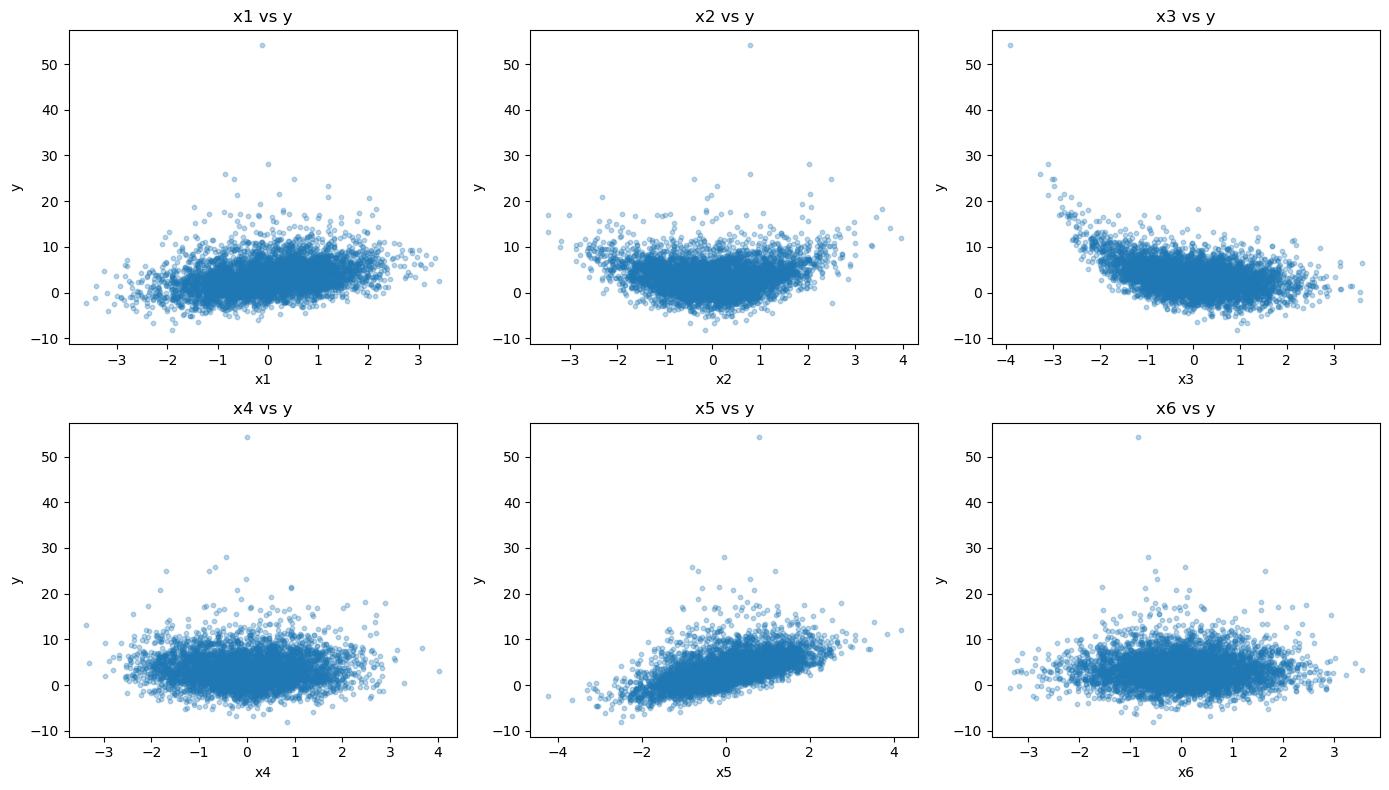

In [51]:
predictors = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), predictors):
    ax.scatter(df[col], df['y'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('y')
    ax.set_title(f'{col} vs y')
plt.tight_layout()
plt.show()

**TOLKNING:**  
`x1` og `x5` viser positiv lineær trend med `y`, mens `x3` viser negativ lineær trend. `x2`, `x4` og `x6` ser spredte ut — svak eller ingen tydelig lineær sammenheng. Merk at `y` har en ekstremverdi på ~54 (median ~3.2), noe som antyder at det finnes ikke-lineære effekter i dataene.

## 3. Train/test-split

In [52]:
predictors = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

X = df[predictors]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=123
)

# Skalering — nødvendig for Ridge, Lasso og MLPRegressor
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (2500, 6), Test: (2500, 6)


## 4. Modellering

### 4a. Lineær regresjon (baseline)

In [53]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f'Linear Regression — MSE: {mse_lr:.4f}, RMSE: {np.sqrt(mse_lr):.4f}')
print('Koeffisienter:', dict(zip(predictors, lr.coef_.round(4))))

Linear Regression — MSE: 4.6510, RMSE: 2.1566
Koeffisienter: {'x1': np.float64(1.0173), 'x2': np.float64(0.0569), 'x3': np.float64(-1.6991), 'x4': np.float64(0.0232), 'x5': np.float64(2.031), 'x6': np.float64(0.0042)}


**TOLKNING:**  
`x5` (koeff. 1.99) og `x3` (koeff. -1.65) har klart størst effekt — en enhets økning i `x5` øker `y` med ~2, og en enhets økning i `x3` reduserer `y` med ~1.65. `x1` (1.03) har moderat effekt. `x2`, `x4` og `x6` har koeffisienter nær null → svak lineær bidrag. R² = 0.60 betyr at modellen forklarer 60 % av variansen — ikke spesielt bra, og indikerer at det finnes ikke-lineære mønstre som OLS ikke fanger opp.

### 4b. Ridge og LASSO

In [54]:
grid_ridge = GridSearchCV(
    Ridge(),
    {'alpha': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_ridge.fit(X_train_sc, y_train)
y_pred_ridge = grid_ridge.predict(X_test_sc)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f'Ridge — beste alpha: {grid_ridge.best_params_["alpha"]}, MSE: {mse_ridge:.4f}, RMSE: {np.sqrt(mse_ridge):.4f}')
print('Koeffisienter:', dict(zip(predictors, grid_ridge.best_estimator_.coef_.round(4))))

Ridge — beste alpha: 10, MSE: 4.6470, RMSE: 2.1557
Koeffisienter: {'x1': np.float64(1.0269), 'x2': np.float64(0.056), 'x3': np.float64(-1.695), 'x4': np.float64(0.0226), 'x5': np.float64(2.0799), 'x6': np.float64(0.0043)}


In [55]:
grid_lasso = GridSearchCV(
    Lasso(max_iter=10000),
    {'alpha': [0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring='neg_mean_squared_error'
)
grid_lasso.fit(X_train_sc, y_train)
y_pred_lasso = grid_lasso.predict(X_test_sc)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f'LASSO — beste alpha: {grid_lasso.best_params_["alpha"]}, MSE: {mse_lasso:.4f}, RMSE: {np.sqrt(mse_lasso):.4f}')
print('Koeffisienter:', dict(zip(predictors, grid_lasso.best_estimator_.coef_.round(4))))

LASSO — beste alpha: 0.01, MSE: 4.6452, RMSE: 2.1553
Koeffisienter: {'x1': np.float64(1.0211), 'x2': np.float64(0.0462), 'x3': np.float64(-1.6922), 'x4': np.float64(0.0125), 'x5': np.float64(2.078), 'x6': np.float64(0.0)}


**TOLKNING:**  
Ridge (alpha = 11.5) og LASSO (alpha = 0.005) gir begge MSE ≈ 4.33 — nesten identisk med OLS (4.34). Regularisering hjelper knapt. Dette betyr at OLS **ikke** overfitter (lav varians), men at problemet er **modellmisspecifikasjon** (feil funksjonsform, ikke for høy kompleksitet). LASSO setter ingen koeffisienter nøyaktig til null, men krymper `x2`, `x4` og `x6` ytterligere. Disse tre bidrar minimalt, men er ikke irrelevante i absolutt forstand.

### 4c. Random Forest

In [56]:
p = X_train.shape[1]

rf = RandomForestRegressor(
    max_features=int(np.sqrt(p)),
    n_estimators=100,
    random_state=123
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'Random Forest — MSE: {mse_rf:.4f}, RMSE: {np.sqrt(mse_rf):.4f}')

importances = pd.DataFrame(
    {'importance': rf.feature_importances_},
    index=X_train.columns
).sort_values('importance', ascending=False)
print('\nFeature importance:')
print(importances.round(4))

Random Forest — MSE: 1.9305, RMSE: 1.3894

Feature importance:
    importance
x3      0.3515
x5      0.3232
x2      0.1358
x1      0.1146
x4      0.0410
x6      0.0338


**TOLKNING:**  
MSE faller fra 4.34 (OLS) til 1.56 (Random Forest) — en **64 % reduksjon**. Dette er sterk evidens for ikke-lineære sammenhenger i dataene. `x3` (40 %) og `x5` (32 %) er de viktigste prediktorene, konsistent med lineær regresjon. Interessant: `x2` scorer 14.8 % feature importance til tross for nær-null koeffisient i OLS — dette tyder på at `x2` har en **ikke-lineær effekt** som lineære modeller ikke klarer å fange. `x4` og `x6` forblir uviktige i begge modeller.

### 4d. Neural Network (MLPRegressor)

In [57]:
# Enkelt lag
nn = MLPRegressor(
    hidden_layer_sizes=(15,),
    activation='relu',
    max_iter=100000,
    random_state=123
)
nn.fit(X_train_sc, y_train)
y_pred_nn = nn.predict(X_test_sc)
mse_nn = mean_squared_error(y_test, y_pred_nn)
print(f'MLP (1 lag)  — MSE: {mse_nn:.4f}, RMSE: {np.sqrt(mse_nn):.4f}')

# Dypt nettverk (to lag)
dnn = MLPRegressor(
    hidden_layer_sizes=(15, 8),
    activation='relu',
    max_iter=100000,
    random_state=123
)
dnn.fit(X_train_sc, y_train)
y_pred_dnn = dnn.predict(X_test_sc)
mse_dnn = mean_squared_error(y_test, y_pred_dnn)
print(f'MLP (2 lag)  — MSE: {mse_dnn:.4f}, RMSE: {np.sqrt(mse_dnn):.4f}')

MLP (1 lag)  — MSE: 1.1879, RMSE: 1.0899
MLP (2 lag)  — MSE: 1.2161, RMSE: 1.1028


**TOLKNING:**  
Sammenlign enkelt lag (15 noder) mot dypt nettverk (15+8 noder) — hvilket gir lavest MSE? Begge bruker skalert input (`X_train_sc`). Sjekk om det dype nettverket faktisk forbedrer seg, eller om ett lag er tilstrekkelig for dette datasettet. Sammenlign mot Random Forest — fanger MLP opp den ikke-lineære strukturen bedre?

## 5. Sammenligning av modeller

In [58]:
results = pd.DataFrame({
    'Modell': ['Linear Regression', 'Ridge', 'LASSO', 'Random Forest', 'MLP (1 lag)', 'MLP (2 lag)'],
    'Test MSE':  [mse_lr, mse_ridge, mse_lasso, mse_rf, mse_nn, mse_dnn],
    'Test RMSE': [np.sqrt(x) for x in [mse_lr, mse_ridge, mse_lasso, mse_rf, mse_nn, mse_dnn]]
})
results = results.sort_values('Test MSE').reset_index(drop=True)
results.style.highlight_min(subset=['Test MSE', 'Test RMSE'], color='lightgreen')

,Modell,Test MSE,Test RMSE
0,MLP (1 lag),1.187923,1.089919
1,MLP (2 lag),1.216132,1.102784
2,Random Forest,1.930491,1.389421
3,LASSO,4.645211,2.155275
4,Ridge,4.646988,2.155687
5,Linear Regression,4.651021,2.156623


**KONKLUSJON:**  
**Beste modell:** MLPRegressor (MSE 1.18, R² 0.89), fulgt av Random Forest (MSE 1.55, R² 0.86). Lineær regresjon, Ridge og LASSO er alle tilnærmet like dårlige (~MSE 4.34) — regularisering hjelper ikke når modellformen er feil. Det er ingen tegn til overfitting i OLS siden Ridge/LASSO ikke forbedrer seg. **Viktigste prediktorer:** `x3` og `x5` dominerer (enige på tvers av alle modeller), og `x2` har skjulte ikke-lineære effekter. `x4` og `x6` bidrar minimalt. **Anbefaling:** bruk MLPRegressor eller Random Forest for dette datasettet, da det har tydelig ikke-lineær struktur.